In [21]:
import os
import glob
import numpy as np
import random
import mne
import matplotlib.pyplot as plt
from scipy.signal import welch
from scipy.stats import entropy

def bandpower(psd, freqs, band):
    fmin, fmax = band
    mask = (freqs >= fmin) & (freqs <= fmax)
    return np.trapz(psd[mask], freqs[mask])

def spectral_entropy(psd):
    psd = np.nan_to_num(psd)
    total = np.sum(psd)
    if total == 0:
        return np.nan
    p = psd / total
    return entropy(p)

def spectral_complexity(psd):
    psd = np.nan_to_num(psd)
    total = np.sum(psd)
    if total == 0:
        return np.nan
    p = psd / total
    uniform = np.ones_like(p) / len(p)
    return entropy(p, uniform)

def load_signal(file, channel):
    raw = mne.io.read_raw_brainvision(file, preload=True, verbose=False)
    raw.pick([channel])
    raw.resample(TARGET_SFREQ)
    x = raw.get_data()[0]

    if np.std(x) < 1e-12:
        return None

    return x

DATA_DIR = "./data/ds006848"
TARGET_SFREQ = 125
WINDOW_SEC = 0.25

bands = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta":  (13, 30),
    "gamma": (30, 40)
}

band_edges = [1,4,8,13,30,40]

In [23]:
subjects = sorted(glob.glob(os.path.join(DATA_DIR, "sub-*")))

rest_files = {}
task_files = {}

for subj_path in subjects:
    subj = os.path.basename(subj_path)

    rest = glob.glob(os.path.join(subj_path, "eeg", "*task-rest*_eeg.vhdr"))
    task = glob.glob(os.path.join(subj_path, "eeg", "*task-*_eeg.vhdr"))

    task = [t for t in task if "task-rest" not in t]

    if len(rest) > 0:
        rest_files[subj] = rest[0]
        if len(task) > 0:
            task_files[subj] = task[0]

subjects = sorted(rest_files.keys())
subjects

['sub-010',
 'sub-016',
 'sub-017',
 'sub-018',
 'sub-020',
 'sub-021',
 'sub-026',
 'sub-027',
 'sub-028']

In [24]:
channel_sets = []

for subj in subjects:
    raw = mne.io.read_raw_brainvision(rest_files[subj], preload=False, verbose=False)
    channel_sets.append(set(raw.ch_names))

print("Channels we can use:", sorted(set.intersection(*channel_sets)))
# channel = sorted(set.intersection(*channel_sets))[0]

channel = 'Cz'
print("Using channel:", channel)

Channels we can use: ['AF3', 'AF4', 'AF7', 'AF8', 'AFz', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'CP1', 'CP2', 'CP3', 'CP4', 'CP5', 'CP6', 'CPz', 'Cz', 'ECG', 'F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7', 'F8', 'FC1', 'FC2', 'FC3', 'FC4', 'FC5', 'FC6', 'FT10', 'FT7', 'FT8', 'FT9', 'Fp1', 'Fp2', 'Fz', 'O1', 'O2', 'Oz', 'P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'PO3', 'PO4', 'PO7', 'PO8', 'POz', 'PPG', 'Pz', 'T7', 'T8', 'TP10', 'TP7', 'TP8', 'TP9']
Using channel: Cz


In [13]:
rest_stats = {}
task_stats = {}
all_signals = []

for subj in subjects:

    # REST
    x = load_signal(rest_files[subj], channel)
    if x is not None:
        freqs, psd = welch(x, fs=TARGET_SFREQ, nperseg=TARGET_SFREQ*2)

        rest_stats[subj] = {
            "freqs": freqs,
            "psd": psd,
            "entropy": spectral_entropy(psd),
            "complexity": spectral_complexity(psd)
        }

        all_signals.append(x)

    # TASK
    if subj in task_files:
        x = load_signal(task_files[subj], channel)
        if x is not None:
            freqs, psd = welch(x, fs=TARGET_SFREQ, nperseg=TARGET_SFREQ*2)

            task_stats[subj] = {
                "freqs": freqs,
                "psd": psd,
                "entropy": spectral_entropy(psd),
                "complexity": spectral_complexity(psd)
            }

            all_signals.append(x)

sub-010 rest flat signal
sub-010 rest flat signal
sub-010 rest flat signal
sub-010 rest flat signal
sub-010 rest flat signal
sub-010 rest flat signal
sub-010 rest no valid channel
sub-017 task flat signal
sub-017 task flat signal
sub-017 task flat signal
sub-017 task flat signal
sub-017 task flat signal
sub-017 task flat signal
sub-017 task no valid channel
sub-018 task non-finite values
sub-018 task non-finite values
sub-018 task non-finite values
sub-018 task non-finite values
sub-018 task non-finite values
sub-018 task non-finite values
sub-018 task no valid channel


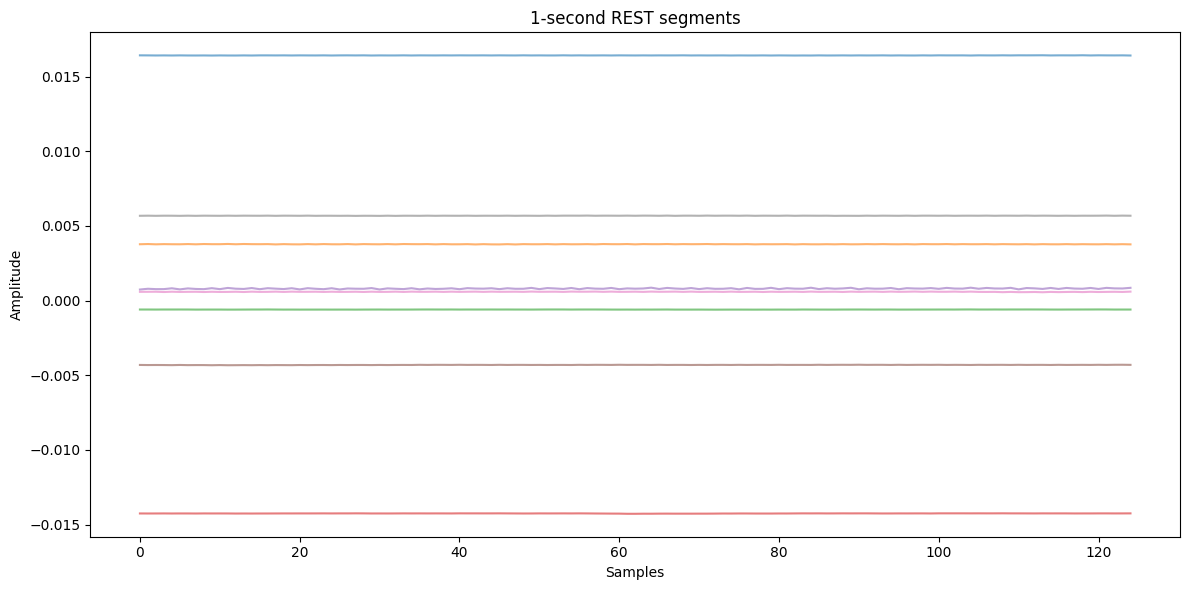

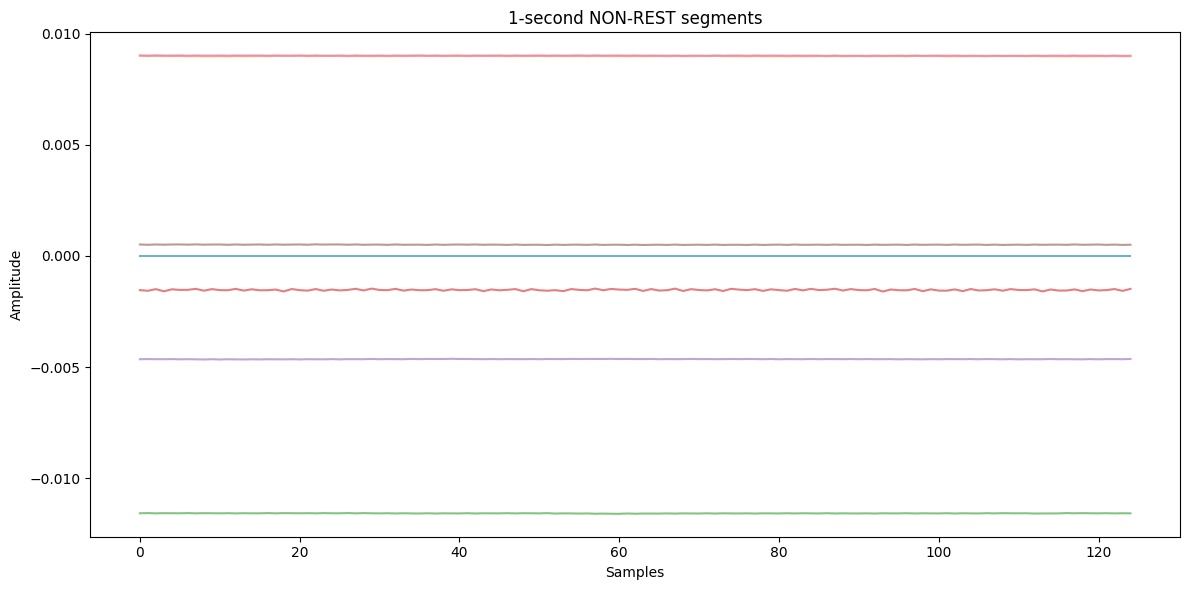

In [25]:
WINDOW_VIS_SEC = 1.0
vis_len = int(WINDOW_VIS_SEC * TARGET_SFREQ)

rest_segments = {}
task_segments = {}
preferred_channels = ["Cz","Pz","Oz","C3","C4","Fz"]
def load_signal_checked(file, ch, subj, label):
    try:
        raw = mne.io.read_raw_brainvision(file, preload=True, verbose=False)

        if ch not in raw.ch_names:
            print(subj, label, "missing channel", ch)
            return None

        if ch in raw.info["bads"]:
            print(subj, label, "channel marked bad")
            return None

        raw.pick([ch])
        raw.resample(TARGET_SFREQ)

        x = raw.get_data()[0]

        if not np.all(np.isfinite(x)):
            print(subj, label, "non-finite values")
            return None

        if np.std(x) < 1e-10:
            print(subj, label, "flat signal")
            return None

        return x

    except Exception as e:
        print(subj, label, "read error:", e)
        return None
def load_best_channel(file, subj, label):
    raw = mne.io.read_raw_brainvision(file, preload=False, verbose=False)
    available = [c for c in preferred_channels if c in raw.ch_names]

    for ch in available:
        x = load_signal_checked(file, ch, subj, label)
        if x is not None:
            return x, ch

    print(subj, label, "no valid channel")
    return None, None
for subj in subjects:

    # REST
    if subj in rest_files:
        x, ch = load_best_channel(rest_files[subj], subj, "rest")
        if x is not None and len(x) > vis_len:
            start = np.random.randint(0, len(x) - vis_len)
            rest_segments[subj] = x[start:start+vis_len]

    # NON-REST
    if subj in task_files:
        x, ch = load_best_channel(task_files[subj], subj, "task")
        if x is not None and len(x) > vis_len:
            start = np.random.randint(0, len(x) - vis_len)
            task_segments[subj] = x[start:start+vis_len]


# ------------------------
# plot REST
# ------------------------
plt.figure(figsize=(12,6))

for subj, seg in rest_segments.items():
    plt.plot(seg, alpha=0.6, label=subj)

plt.title("1-second REST segments")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()


# ------------------------
# plot NON-REST
# ------------------------
plt.figure(figsize=(12,6))

for subj, seg in task_segments.items():
    plt.plot(seg, alpha=0.6, label=subj)

plt.title("1-second NON-REST segments")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

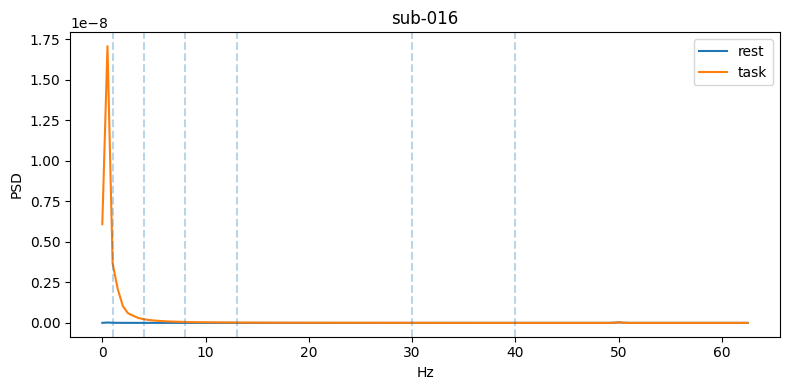

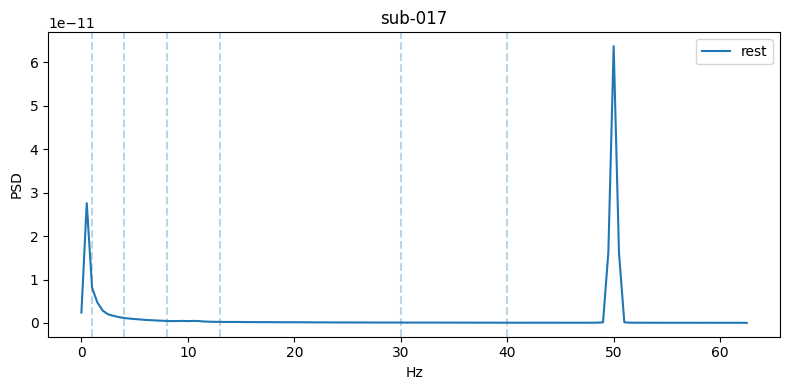

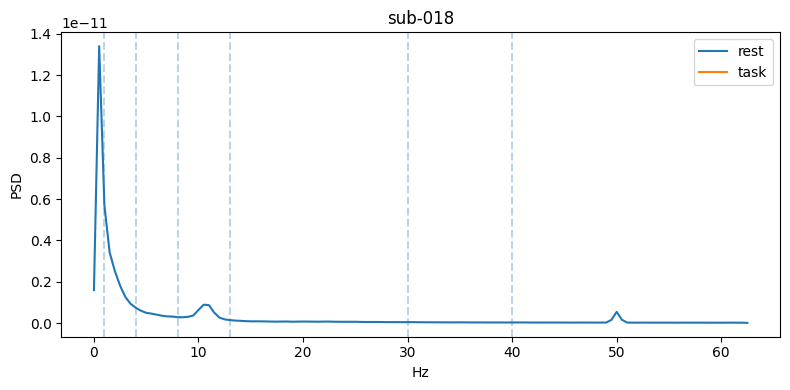

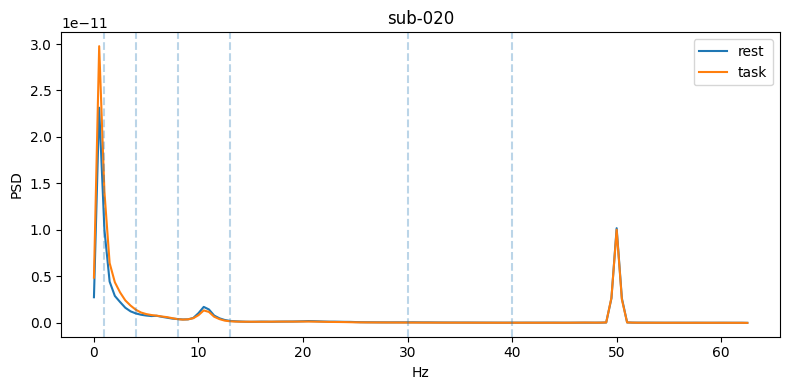

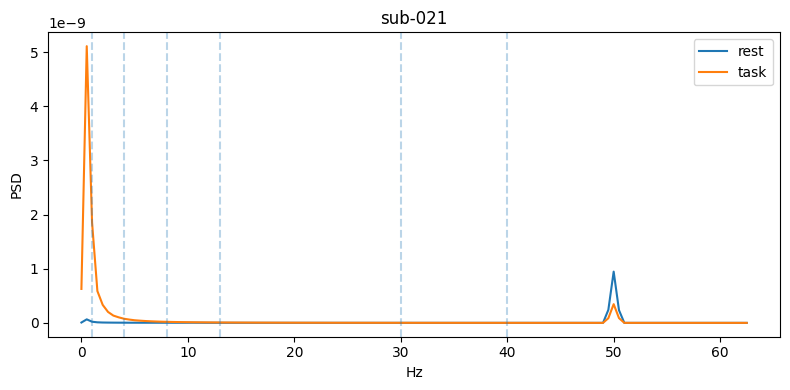

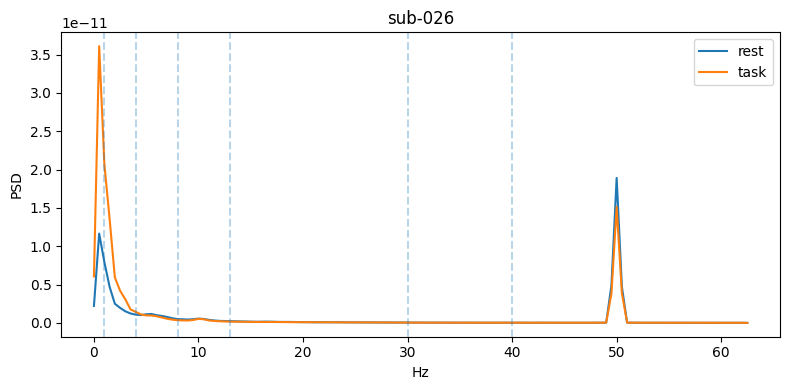

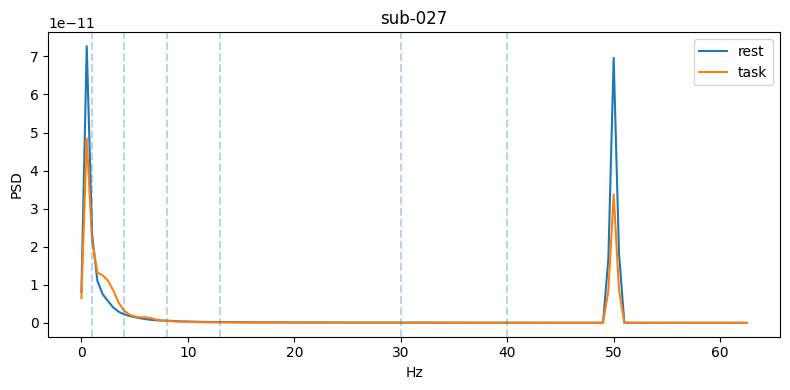

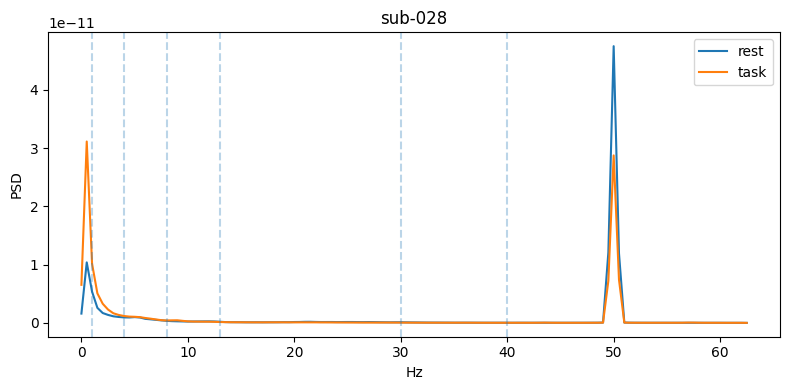

In [14]:
for subj in subjects:

    if subj not in rest_stats:
        continue

    plt.figure(figsize=(8,4))

    r = rest_stats[subj]
    plt.plot(r["freqs"], r["psd"], label="rest")

    if subj in task_stats:
        t = task_stats[subj]
        plt.plot(t["freqs"], t["psd"], label="task")

    for b in band_edges:
        plt.axvline(b, linestyle="--", alpha=0.3)

    plt.title(subj)
    plt.xlabel("Hz")
    plt.ylabel("PSD")
    plt.legend()
    plt.tight_layout()
    plt.show()

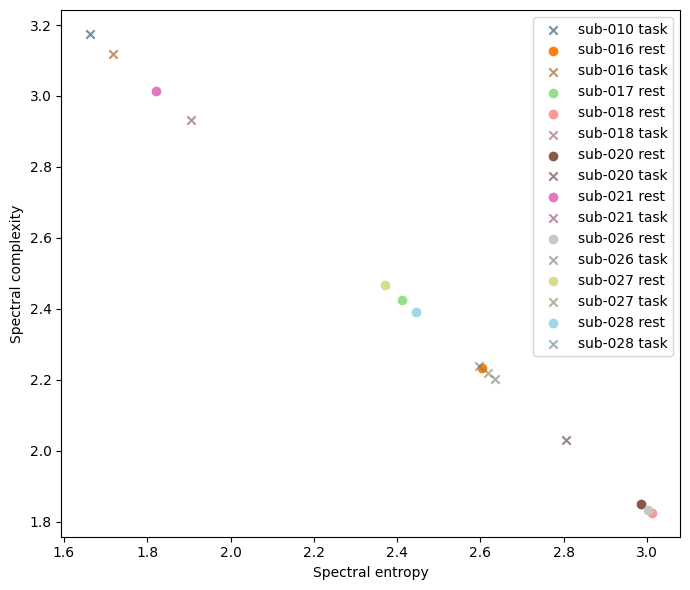

In [17]:
plt.figure(figsize=(7,6))

colors = plt.cm.tab20(np.linspace(0,1,len(subjects)))

for i, subj in enumerate(subjects):

    base = colors[i]

    if subj in rest_stats:
        plt.scatter(
            rest_stats[subj]["entropy"],
            rest_stats[subj]["complexity"],
            color=base,
            marker="o",
            label=subj+" rest"
        )

    if subj in task_stats:
        plt.scatter(
            task_stats[subj]["entropy"],
            task_stats[subj]["complexity"],
            color=base*0.6,
            marker="x",
            label=subj+" task"
        )

plt.xlabel("Spectral entropy")
plt.ylabel("Spectral complexity")
plt.tight_layout()
plt.legend()
plt.show()

In [18]:
window_len = int(WINDOW_SEC * TARGET_SFREQ)

full = np.concatenate(all_signals)

starts = list(range(0, len(full)-window_len, window_len))
random.shuffle(starts)

starts = starts[:10]
windows = np.array([full[s:s+window_len] for s in starts])

print("windows:", windows.shape)

windows: (10, 31)
